In [6]:
##Testing catboost decision trees on the receptor kinase evolution data
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool, cv, EShapCalcType, EFeaturesSelectionAlgorithm
from catboost.utils import get_roc_curve, select_threshold
#from sklearn import tree
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.preprocessing import StandardScaler
#from sklearn.multiclass import OneVsRestClassifier 
#from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from skopt.space import Integer, Real
from sklearn.metrics import RocCurveDisplay
from skopt import gp_minimize
from Optimize_catboost import perform_search
import matplotlib.pyplot as plt
import seaborn as sn







In [2]:
####useful functions

def optimize_model_search(optimize_model_flag, search_type, xtrain, ytrain):
#if optimization is turned on, call the optimization script. Otherwise, use manual 

    print("Optimizing model")
    consistent_params = [("loss_function", "Logloss",),
                    ("early_stopping_rounds",50),
                    ("eval_metric", "Accuracy"),
                    ("auto_class_weights","Balanced"),
                    ("verbose", 100)]
    
    if optimize_model_flag == True:
        model_params = perform_search(xtrain, ytrain, CatBoostClassifier(**dict(consistent_params)), search_type)
        model_params.update(consistent_params)
        model = CatBoostClassifier(**model_params)

    else: 
        model = CatBoostClassifier(
            #bagging_temperature=1,
            depth=9, #best is 10, cv 2
            #l2_leaf_reg=5, #5, 35 
            #random_strength=210, #210, 5
            #learning_rate=0.033896, #0.03, 0.05
            verbose=100,
            iterations=403,
            subsample = 0.30465983174171796,
            loss_function='Logloss',
            early_stopping_rounds=50,
            eval_metric="Accuracy",
            custom_metric=['F1', 'Precision', 'Recall', "BalancedAccuracy"],
            auto_class_weights='Balanced'
        )

    return(model)

###end model optimization function






In [ ]:
####import data#####
df_train = pd.read_csv('RKTrainSet.csv')
#df_predict = pd.read_csv('RKTestSet.csv')
print("Loading data")

#Need to change the output to numbers so it'll work fine. Catboost natively does this for binary, but I have it
#setup here for multiclass if wanted
target_dict = {'Non-Defense':0, 'Defense':1,'Both':2}




##get data and split for training set
features = df_train.drop(["Gene", "Most similar gene", "Category"], axis=1)
target = df_train["Category"]

#print(len(target))




#mlb = MultiLabelBinarizer()
#y_binarized = mlb.fit_transform()

#print(y_binarized)

#exit()


print("Splitting train/test")
#split data
xtrain, xtest, ytrain, ytest = train_test_split(
    features, 
    target,
    random_state=2023,
    test_size=0.2
)

ytrain = ytrain.map(target_dict)
ytest = ytest.map(target_dict)




categorical_features = xtrain.select_dtypes("str").columns.tolist()





###model hyperparameters and assignment
#best for cv is in the comments











#model = optimize_model_search(optimize_model_flag, search_type, xtrain=xtrain, ytrain=ytrain)

    # bagging_temperature=1,
    #     depth=2, #best is 10, cv 2
    #     l2_leaf_reg=5, #5, 35 
    #     random_strength=5, #210, 5
    #     learning_rate=0.0017318776075766065, #0.03, 0.05
    #     verbose=100,
    #     iterations=493,
    #     subsample = 0.26991358619066463,
    #     loss_function='Logloss',
    #     early_stopping_rounds=50,
    #     eval_metric="Accuracy",
    #     custom_metric=['F1', 'Precision', 'Recall', "BalancedAccuracy"],
    #     auto_class_weights='Balanced'

    

#feature selection 

#feature_names = ['F{}'.format(i) for i in range(xtrain.shape[1])]

feature_names = ['{}'.format(i) for i in xtrain.columns]
#print(feature_names)

trainpool = Pool(xtrain, ytrain, feature_names=feature_names, cat_features=categorical_features)
testpool = Pool(xtest, ytest, feature_names=feature_names, cat_features=categorical_features)

num_features_for_select_str = "0-" + str(len(feature_names)-1)
#print(num_features_for_select_str)



#model optimization flag
optimize_model_flag = True
search_type = "bayesian"
model = optimize_model_search(optimize_model_flag, search_type, xtrain=xtrain, ytrain=ytrain)

model_summary = model.select_features(
    trainpool,
    eval_set = testpool,
    features_for_select=num_features_for_select_str,
    num_features_to_select=6,
    steps=3,
    algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
    shap_calc_type=EShapCalcType.Regular,
    train_final_model=False,
    logging_level='Silent',
    plot=False


)

print(model_summary)

#print(model_summary['eliminated_features_names'])

###since we figured optimal features, change the train and test sets and go from there
xtrain = xtrain.drop(model_summary['eliminated_features_names'], axis=1)
xtest = xtest.drop(model_summary['eliminated_features_names'], axis=1)




Loading data
Splitting train/test
Optimizing model
{'selected_features': [6, 8, 9, 10, 11, 12], 'eliminated_features_names': ['Num_Pos_Sites', 'Neg_ECD', 'Neg_Kinase', 'Num_Neg_Sites', 'Nonsyn_syn_ratio_ECD', 'Nonsyn_syn_ratio_KD', 'Pos_ECD', 'ECD_Ratio', 'Ratio'], 'loss_graph': {'main_indices': [0, 4, 7], 'removed_features_count': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'loss_values': [0.6775513488634244, 0.6332833157925553, 0.5891325796965226, 0.5632874522626969, 0.5632874522626969, 0.6450627728675274, 0.6591852913266548, 0.6538055671856465, 0.6536858794901977, 0.6536858794901977]}, 'eliminated_features': [0, 4, 7, 1, 13, 14, 3, 5, 2], 'selected_features_names': ['Pos_Kinase', 'Kinase_Ratio', 'Family', 'Pangenome', 'Duplication', 'Nonsyn_syn_ratio']}


In [ ]:


print("Training model")
#fit the model and output the training accuracy. Then look at testing accuracy 
model.fit(xtrain, ytrain, eval_set=(xtrain,ytrain), cat_features = categorical_features, use_best_model=True)

# ##get feature importance for model fixing
# feature_importance = model.get_feature_importance()
# importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance}).sort_values(by='Importance', ascending=False)
# print(importance_df)


# plt.figure(figsize=(10, 6))
# sns.barplot(x='Importance', y='Feature', data=importance_df)
# plt.title('CatBoost Feature Importance')
# plt.show()



#######


roc_curve_values = get_roc_curve(model, Pool(xtrain, ytrain, cat_features=categorical_features), plot=False)

#print(roc_curve_values['fpr'])
#print(roc_curve_values['tpr'])
#print(roc_curve_values['thresholds'])

target_fpr = 0.01
optimal_threshold = select_threshold(model, curve=roc_curve_values)
print(f"Optimal Threshold for {target_fpr*100}% FPR: {optimal_threshold}")

model.set_probability_threshold(optimal_threshold)
ypred = model.predict(xtest)   #get prediction
yprob = model.predict_proba(xtest)[:,1]  #get probability
#yprob = (yprob > optimal_threshold).astype(int)


accuracy = accuracy_score(ytest,ypred)
#accuracy = model.score(xtest,ytest)
f1score = f1_score(ytest, ypred, average='weighted')
roc_auc = roc_auc_score(ytest, yprob)
#print('Classification report:')






#print(model.get_best_score()['validation'])
#print(f"ROC AUC Score: {roc_auc:.4f}")

print(f"Accuracy: {accuracy}", f"f1: {f1score}", f"ROC AUC: {roc_auc:.4f}")
###
# print(f"Accuracy: {model.get_best_score()['validation']['Accuracy']}", 
#       f"f1: {model.get_best_score()['validation']['F1']}", 
#       f"Precision: {model.get_best_score()['validation']['Precision']}",
#       f"Recall: {model.get_best_score()['validation']['Recall']}")
# ###



Training model
Learning rate set to 0.033896
0:	learn: 0.6201299	test: 0.6017316	best: 0.6017316 (0)	total: 9.91ms	remaining: 3.98s
100:	learn: 0.9380952	test: 0.8740260	best: 0.8783550 (99)	total: 1.7s	remaining: 5.09s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8835497835
bestIteration = 127

Shrink model to first 128 iterations.
Optimal Threshold for 1.0% FPR: 0.499405799411648
              precision    recall  f1-score   support

           0       0.55      0.67      0.60        18
           1       0.87      0.80      0.83        49

    accuracy                           0.76        67
   macro avg       0.71      0.73      0.71        67
weighted avg       0.78      0.76      0.77        67

Accuracy: 0.7611940298507462 f1: 0.7680533502699269 ROC AUC: 0.8124


[[12  6]
 [10 39]]


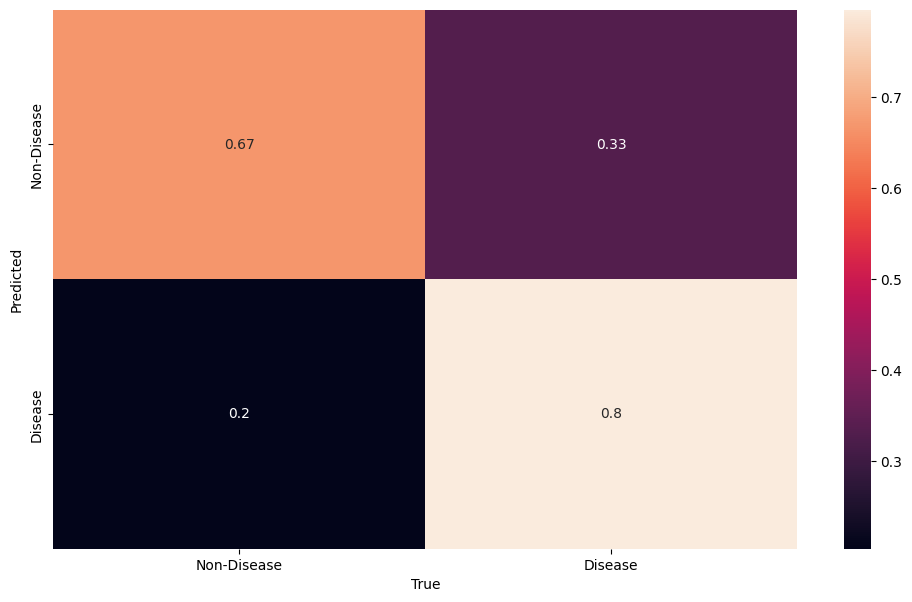

In [ ]:
cf_matrix = confusion_matrix(y_pred=ypred, y_true=ytest)

#print(cf_matrix)

df_cm = pd.DataFrame(cf_matrix / np.sum(cf_matrix, axis=1)[:,None], index=["Non-Disease","Disease"], columns=["Non-Disease","Disease"])

plt.close()
plt.figure(figsize = (12, 7))
sn.heatmap(df_cm, annot=True)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

              precision    recall  f1-score   support

 Non-Disease       0.55      0.67      0.60        18
     Disease       0.87      0.80      0.83        49

    accuracy                           0.76        67
   macro avg       0.71      0.73      0.71        67
weighted avg       0.78      0.76      0.77        67



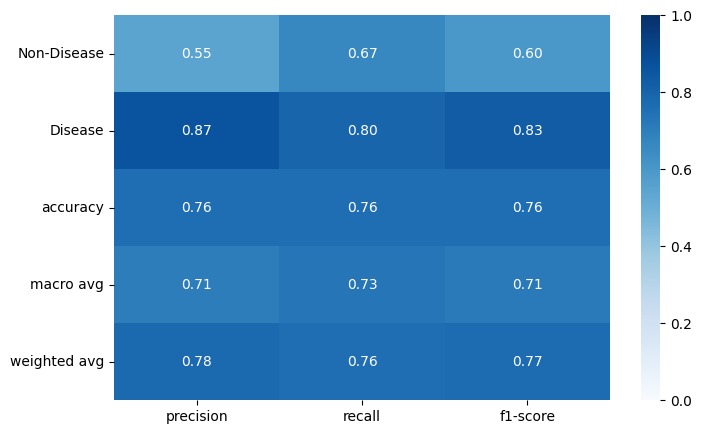

In [27]:
print(classification_report(ytest, ypred, target_names = ["Non-Disease","Disease"]))


class_report_df = pd.DataFrame(classification_report(ytest, ypred,output_dict=True, target_names = ["Non-Disease","Disease"]))
class_report_vals = class_report_df.iloc[:-1,:].T
class_report_support = class_report_df.iloc[:, -1]

plt.figure(figsize=(8,5))
sn.heatmap(class_report_vals, annot=True, cmap="Blues", fmt=".2f", vmin=0.0, vmax=1.0)
plt.show()

In [ ]:


cv_results = cv(
   pool=Pool(xtest,ytest,cat_features=categorical_features),
   params=model.get_params(),
   fold_count=5,
   shuffle=True,
   stratified=True
)

print(cv_results.tail(1))
best_accuracy = cv_results['test-Accuracy-mean'].max()
print(f"Best mean validation accuracy: {best_accuracy}")


#RocCurveDisplay.from_predictions(model, ytest, ypred)
#plt.title('Received Operating Characeristic')
#plt.show()
# Save the model in the default CBM format
#model.save_model('CatboostModel_RKs.cbm') 